# <center>  Dog Breed Predict

##### My Github:ARSALANnam(Echolyno)
##### My Email: arsalannam9710@gmail.com
##### My Linkedin:www.linkedin.com/in/arsalannam

### This project is a deep learning-based dog breed classification system developed using TensorFlow and Keras. The model is trained on the Kaggle Dog Breed Identification dataset containing 120 dog breeds and uses Transfer Learning with MobileNetV2 to achieve accurate multi-class image classification. Techniques such as data augmentation, fine-tuning, dropout regularization, and learning rate scheduling were applied to improve performance and reduce overfitting.

# Importing libraries and modules <a name = 'h2'></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import tensorflow as tf

from tqdm import tqdm # Progress bar
from keras.preprocessing import image # For Image Loading and Prepocessing

from sklearn.preprocessing import label_binarize # For one-hot encoding of labels
from sklearn.model_selection import train_test_split # For splitting data into train/test sets

from sklearn.metrics import confusion_matrix

from keras.models import Sequential 
from keras.optimizers import Adam 
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from tensorflow.keras.layers import RandomFlip, RandomRotation, RandomZoom, RandomTranslation, RandomContrast

from tensorflow.keras.callbacks import EarlyStopping

In [3]:
print(tf.test.gpu_device_name())

/device:GPU:0


I0000 00:00:1778602811.057503   14515 gpu_device.cc:2020] Created device /device:GPU:0 with 3554 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


# Dataset Source

https://www.kaggle.com/datasets/catherinehorng/dogbreedidfromcomp/data

In [4]:
labels_first = pd.read_csv("../Dataset/labels.csv")
print(labels_first.shape)

(10222, 2)


In [5]:
labels_first.head()

,id,breed
0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,001cdf01b096e06d78e9e5112d419397,pekinese
3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [6]:
breeds = labels_first["breed"]
breed_counts = breeds.value_counts()
breed_counts.head()

breed
scottish_deerhound      126
maltese_dog             117
afghan_hound            116
entlebucher             115
bernese_mountain_dog    114
Name: count, dtype: int64

In [7]:
CLASS_NAMES = list(labels_first['breed'].unique())
labels = labels_first.copy()
labels = labels.reset_index()
labels.head()

,index,id,breed
0,0,000bec180eb18c7604dcecc8fe0dba07,boston_bull
1,1,001513dfcb2ffafc82cccf4d8bbaba97,dingo
2,2,001cdf01b096e06d78e9e5112d419397,pekinese
3,3,00214f311d5d2247d5dfe4fe24b2303d,bluetick
4,4,0021f9ceb3235effd7fcde7f7538ed62,golden_retriever


In [8]:
print(len(CLASS_NAMES))

120


#  Breed Distribution Visualization

/tmp/ipykernel_14515/3569864027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


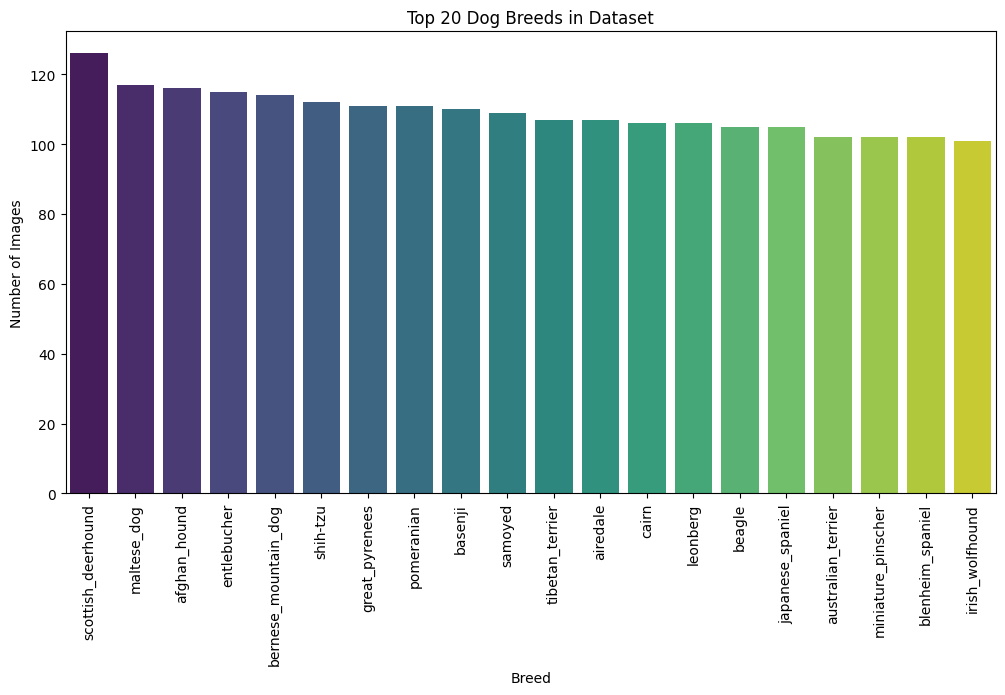

In [9]:
plt.figure(figsize=(12,6))

breed_counts = labels_first['breed'].value_counts()

sns.barplot(
    x=breed_counts.index[:20],
    y=breed_counts.values[:20],
    palette="viridis"
)

plt.xticks(rotation=90)
plt.title("Top 20 Dog Breeds in Dataset")
plt.xlabel("Breed")
plt.ylabel("Number of Images")

plt.show()


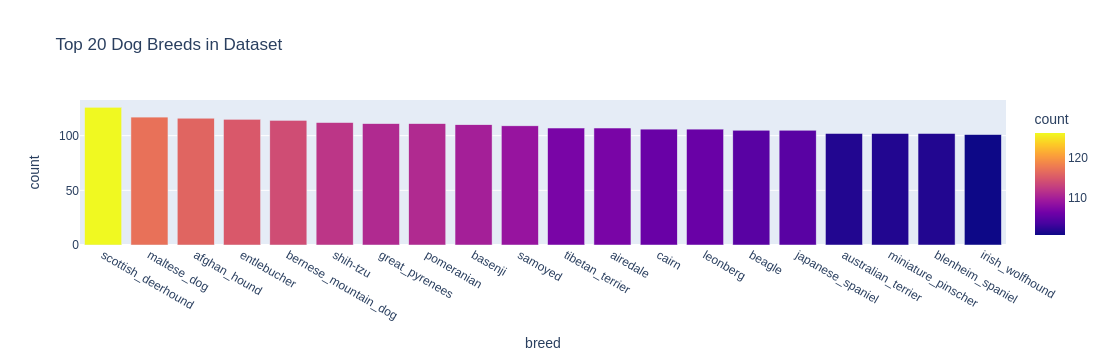

In [10]:
breed_counts = labels_first['breed'].value_counts().reset_index()
breed_counts.columns = ["breed", "count"]

fig = px.bar(
    breed_counts.head(20),
    x="breed",
    y="count",
    title="Top 20 Dog Breeds in Dataset",
    color="count"
)

fig.show()

# Creating numpy matrix with zeros

In [11]:
X_data = np.zeros((len(labels), 192, 192, 3), dtype='float32')

# One hot encoding

In [12]:
Y_data = label_binarize(labels['breed'], classes = CLASS_NAMES)

# Reading and converting image to numpy array and normalizing dataset

In [13]:
for i in tqdm(range(len(labels))):
    img = image.load_img('../Dataset/train/%s.jpg' % labels['id'][i], target_size=(192, 192))
    img = image.img_to_array(img)
    x = np.expand_dims(img.copy(), axis=0)
    X_data[i] = x / 255.0

100%|███████████████████████████████████| 10222/10222 [00:08<00:00, 1194.09it/s]


In [14]:
print('\nTrain Images shape: ',X_data.shape,' size: {:,}'.format(X_data.size))
print('One-hot encoded output shape: ',Y_data.shape,' size: {:,}'.format(Y_data.size))


Train Images shape:  (10222, 192, 192, 3)  size: 1,130,471,424
One-hot encoded output shape:  (10222, 120)  size: 1,226,640


# Train Test Split ( Split dataset into train/validation/test )

In [15]:
X_train_and_val, X_test, Y_train_and_val, Y_test = train_test_split(X_data, Y_data, test_size = 0.3, random_state=42)
X_train, X_val, Y_train, Y_val = train_test_split(X_train_and_val, Y_train_and_val, test_size = 0.3, random_state=42)

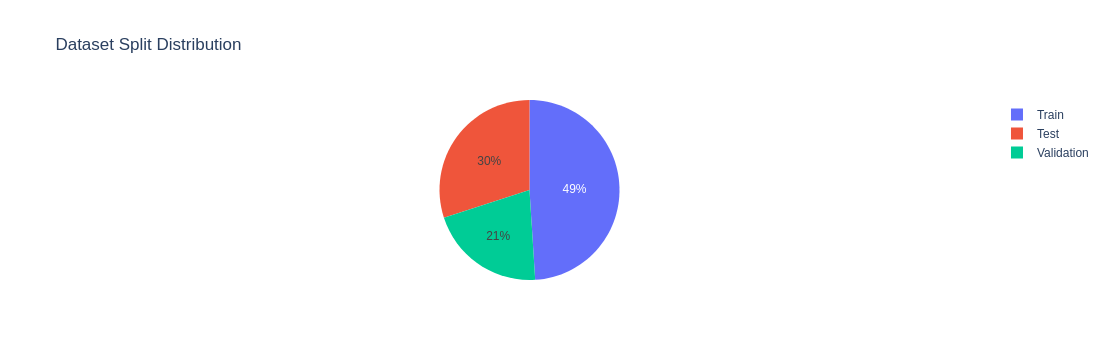

In [16]:
import plotly.graph_objects as go

labels = ['Train', 'Validation', 'Test']
values = [len(X_train), len(X_val), len(X_test)]

fig = go.Figure(data=[go.Pie(labels=labels, values=values)])

fig.update_layout(title="Dataset Split Distribution")

fig.show()


# Building the Model

In [18]:
data_augmentation = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomContrast(0.1),
    RandomTranslation(0.1, 0.1),
], name="data_augmentation")

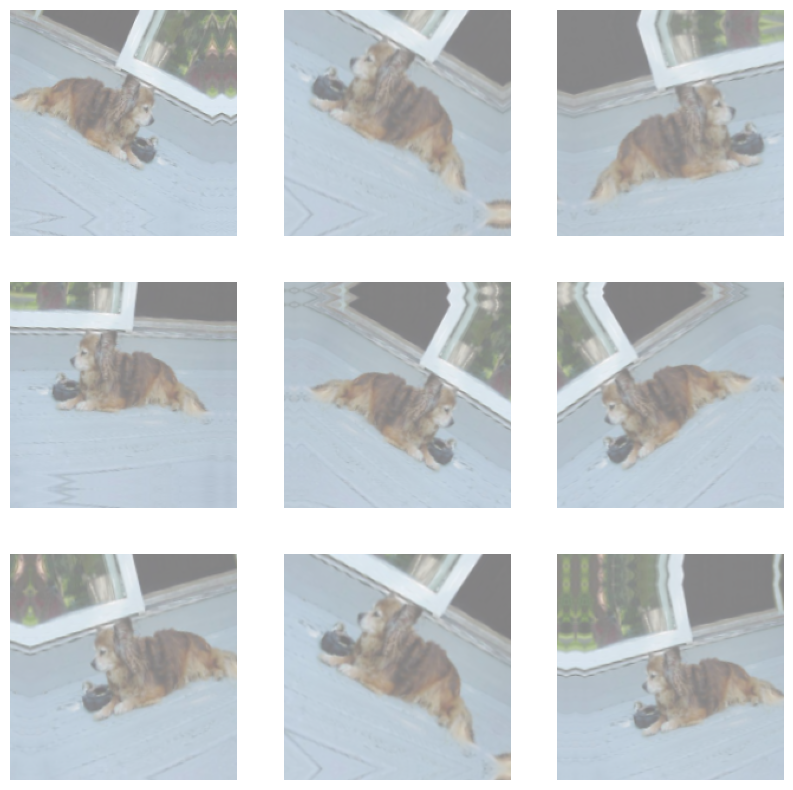

In [68]:
sample = X_train[:1]

plt.figure(figsize=(10,10))
for i in range(9):
    augmented_image = data_augmentation(sample, training=True)
    ax = plt.subplot(3,3,i+1)
    plt.imshow((augmented_image[0] + 1) / 2) 
    plt.axis("off")
plt.show()

In [20]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(192,192,3))

base_model.trainable = False

model = Sequential([
    data_augmentation,
    base_model,
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(len(CLASS_NAMES), activation='softmax')])

In [21]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

# Training the model

In [22]:
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

Physical devices cannot be modified after being initialized


In [23]:
es = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True)

In [24]:
history = model.fit(X_train, Y_train, 
    batch_size = 8, 
    epochs = 15, 
    validation_data = (X_val, Y_val), 
    callbacks=[es])

Epoch 1/15


2026-05-12 19:51:14.319732: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


626/626 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.1162 - loss: 4.1983 - val_accuracy: 0.4001 - val_loss: 2.9611
Epoch 2/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.3363 - loss: 2.7814 - val_accuracy: 0.5585 - val_loss: 1.9252
Epoch 3/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4437 - loss: 2.1730 - val_accuracy: 0.6199 - val_loss: 1.5342
Epoch 4/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.4988 - loss: 1.8873 - val_accuracy: 0.6344 - val_loss: 1.3776
Epoch 5/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5427 - loss: 1.6857 - val_accuracy: 0.6614 - val_loss: 1.2564
Epoch 6/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5711 - loss: 1.5729 - val_accuracy: 0.6665 - val_loss: 1.2064
Epoch 7/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.5984 - loss: 1.4597 - val_accuracy: 0.6670 - val_loss: 1.1564
Epoch 8/15
626/626 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - accuracy: 0.6214 - loss: 1.3575 - val_accurac

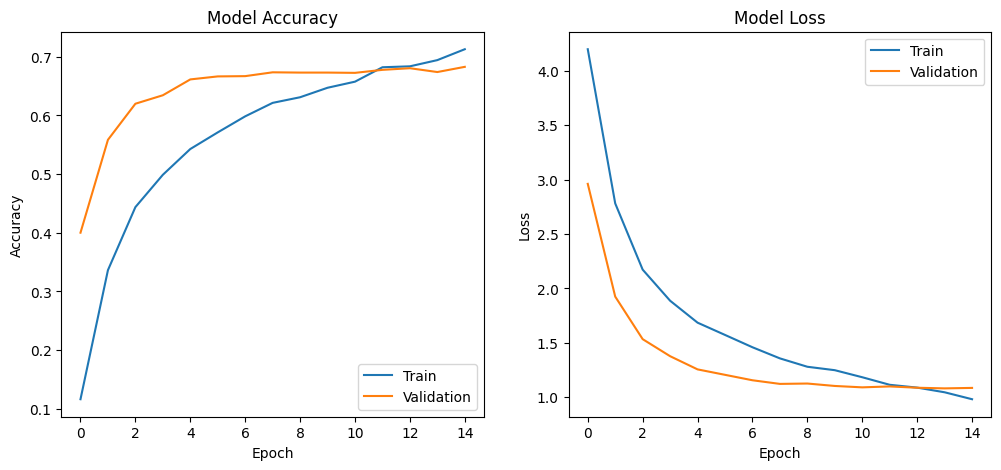

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# Evaluate

In [26]:
Y_pred = model.predict(X_test)
score = model.evaluate(X_test, Y_test)
print('Accuracy over the test set: \n ', round((score[1]*100), 2), '%')

96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - accuracy: 0.6824 - loss: 1.1012
Accuracy over the test set: 
  68.24 %


# Visualize & prediction

96/96 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step


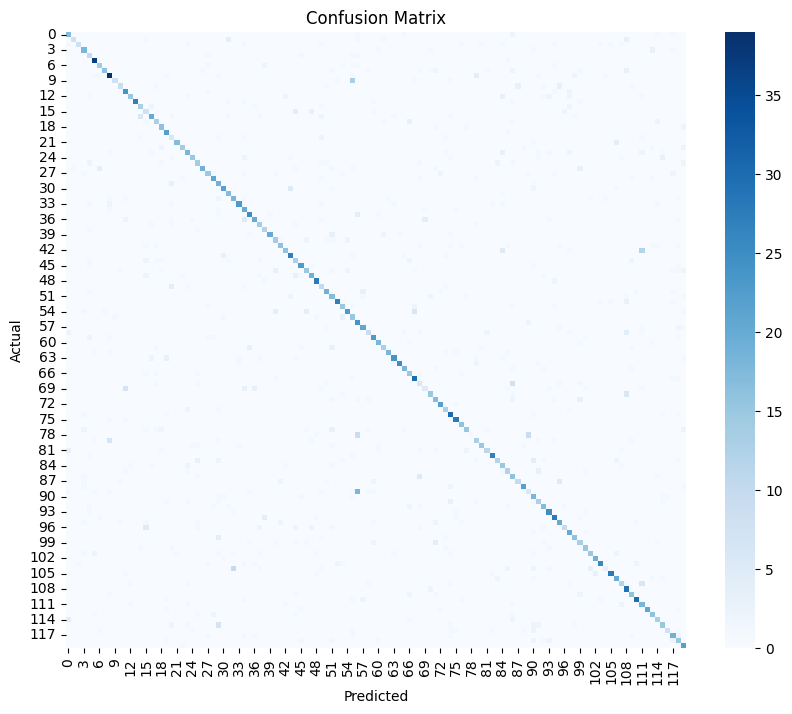

In [27]:
y_pred = model.predict(X_test)
y_pred_classes = y_pred.argmax(axis=1)
y_true = Y_test.argmax(axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

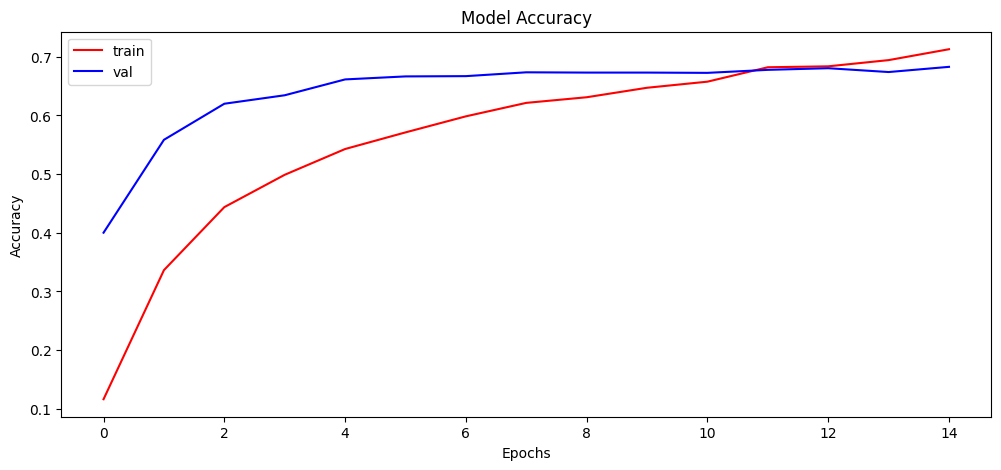

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(history.history['accuracy'], color='r')
plt.plot(history.history['val_accuracy'], color='b')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epochs')
plt.legend(['train', 'val'])

plt.show()

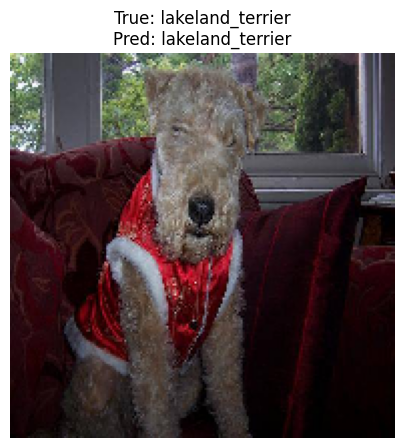

In [66]:
idx = 1000
true_label = CLASS_NAMES[np.argmax(Y_test[idx])]
pred_label = CLASS_NAMES[np.argmax(Y_pred[idx])]

plt.figure(figsize=(5,5))
plt.imshow(X_test[idx])
plt.title(f"True: {true_label}\nPred: {pred_label}")
plt.axis("off")
plt.show()

# For Deploy

In [51]:
model.save("dog_breed.keras")

In [52]:
import json
with open("class_names.json", "w") as f:
    json.dump(CLASS_NAMES, f)

# Thank you for your Support 🤗

Don’t Just Be Another Brick in the Wall 🧱